# Did Netflix’s Password Sharing Crackdown Grow Its Subscriber Base?

This analysis evaluates whether Netflix’s 2022–2023 password-sharing crackdown 
causally increased subscriber growth and monetization.

In early 2022, Netflix experienced its first subscriber loss in over a decade,  
prompting concerns that widespread password sharing was eroding its paying user base. 
The company responded with a paid sharing policy, rolled out in a staggered manner across regions. 
The key question is whether this policy successfully converted non-paying users into 
 subscribers — or instead triggered cancellations.


## Causal question
 What is the causal effect of Netflix’s password-sharing crackdown on subscriber growth and revenue?

## Strategy
Because the policy was rolled out at different times across regions, the control 
group is time-varying (i.e., “not-yet-treated” regions), making this a staggered 
DDD setting. To isolate the effect more cleanly, we extend the original DiD 
to a Triple Difference (DDD) design:

- **Time difference:** Before vs after crackdown 
- **Within-Netflix difference:** Regions with crackdown vs not-yet-treated regions  
- **Across-platform difference:** Netflix vs other streaming platforms (e.g., Disney+)    

This approach helps separate the policy’s impact from confounding factors such as:

- Post-COVID normalization in streaming demand
- Content release cycles
- Macroeconomic conditions

## Data
A panel dataset with 3 dimensions: Region × Time × Platform

**Core Variables:**
- Netflix subscribers by region
- Netflix revenue / ARPU
- Disney+ subscriber data by regions

**Additional constructed variables:**
- Treatment indicator (by region × time)
- Platform indicator (Netflix = 1, others = 0)
- Interaction terms (for triple diff)

**Sample Requirements:**
- Multiple regions 
- Multiple platforms (Netflix & Disney+)
- Pre + post periods 


A major fact to keep in mind is that this crackdown was not uniform. It was implemented in different regions in different quarters
| Region | Treatment Start               |
| ------ | ----------------------------- |
| LATM  | 2022 Q3                  |
| EMEA   | 2023 Q1                       |
| UCAN   | 2023 Q2                       |
| APAC   | 2023 Q2                       |



## Setting up Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)
REGION_COLORS = {
    "UCAN": "#E50914",
    "EMEA": "#2563EB",
    "LATM": "#B91C1C",
    "APAC": "#374151",
}
 
RED = "#E50914"
BLUE= "#2563EB"
GRAY= "#374151"


def section(title):
    print("\n" + "═" * 65)
    print(f"  {title}")
    print("═" * 65)

## Loading Netflix Data

We begin by loading Netflix’s quarterly financial and subscriber data, sourced from SEC filings (10-Q and 8-K reports), covering the period from Q1 2019 to Q1 2024. This dataset forms the foundation of our panel analysis.

The raw data is structured at the quarter level, with each row representing a single reporting period

In [2]:
section("STEP 1: LOAD & RESHAPE NETFLIX DATA")

nf_raw = pd.read_csv("data/netflix_revenue_updated.csv")

# Removing extra spaces from column names, parsing dates, and sorting by date
nf_raw.columns = nf_raw.columns.str.strip()
nf_raw["Date"] = pd.to_datetime(nf_raw["Date"], dayfirst=True)
nf_raw = nf_raw.sort_values("Date").reset_index(drop=True)

print(
    f"  Raw data: {nf_raw.shape[0]} rows (one per quarter), {nf_raw.shape[1]} columns"
)
print(f"  Date range: {nf_raw['Date'].min().date()} → {nf_raw['Date'].max().date()}")
print(f"  Columns: {list(nf_raw.columns)}")


═════════════════════════════════════════════════════════════════
  STEP 1: LOAD & RESHAPE NETFLIX DATA
═════════════════════════════════════════════════════════════════
  Raw data: 21 rows (one per quarter), 15 columns
  Date range: 2019-03-31 → 2024-03-31
  Columns: ['Date', 'Global Revenue', 'UCAN Streaming Revenue', 'EMEA Streaming Revenue', 'LATM Streaming Revenue', 'APAC Streaming Revenue', 'UCAN Members', 'EMEA  Members', 'LATM Members', 'APAC Members', 'UCAN ARPU', 'EMEA ARPU', 'LATM  ARPU', 'APAC  ARPU', 'Netflix Streaming Memberships']


At this stage, the data is still in a wide format (separate columns for each region).
For causal analysis, we have to reshape it into a long panel format (Region × Time), which is required for regression-based estimation.

In [3]:
regions = {
    "UCAN": {
        "members": "UCAN Members",
        "revenue": "UCAN Streaming Revenue",
        "arpu": "UCAN ARPU",
    },
    "EMEA": {
        "members": "EMEA  Members",
        "revenue": "EMEA Streaming Revenue",
        "arpu": "EMEA ARPU",
    },
    "LATM": {
        "members": "LATM Members",
        "revenue": "LATM Streaming Revenue",
        "arpu": "LATM  ARPU",
    },
    "APAC": {
        "members": "APAC Members",
        "revenue": "APAC Streaming Revenue",
        "arpu": "APAC  ARPU",
    },
}
panels = []
for region, cols in regions.items():
    tmp = nf_raw[["Date", cols["members"], cols["revenue"], cols["arpu"]]].copy()
    tmp.columns = ["date", "members", "revenue", "arpu"]
    tmp["region"] = region
    panels.append(tmp)

nf = (
    pd.concat(panels, ignore_index=True)
    .sort_values(["region", "date"])
    .reset_index(drop=True)
)

print(f"\n  After reshape (wide → long):")
print(
    f"    {nf.shape[0]} rows  ({nf['region'].nunique()} regions × {nf['date'].nunique()} quarters)"
)
print(f"    Columns: {list(nf.columns)}")


  After reshape (wide → long):
    84 rows  (4 regions × 21 quarters)
    Columns: ['date', 'members', 'revenue', 'arpu', 'region']


## COMPUTING NET ADDS, REVENUE CHANGE & TREATMENT INDICATOR

In this step, we construct the key variables required for causal analysis:
- The outcome variable (Y)
- The treatment indicator
- Supporting variables for event timing and interpretation

Our primary outcome is quarterly net subscriber additions, defined as:

$$ Net Adds = Subscribers(t) − Subscribers(t−1)$$

Using raw subscriber levels would be misleading because:
- Regions differ significantly in size (e.g., UCAN vs APAC)
- Trends in levels are strongly upward and non-stationary

By using changes, we focus on incremental growth, which is more appropriate for causal inference.

We define treatment based on the **staggered rollout** of Netflix’s paid sharing policy across regions:

| Region | Treatment Start |
| ------ | --------------- |
| LATM  | Q3 2022         |
| UCAN   | Q2 2023         |
| EMEA   | Q3 2023         |
| APAC   | Q3 2023         |

Using these dates, we construct:

* **`treated` = 1** if a region has implemented the crackdown in a given quarter
* **`treated` = 0** otherwise


We also compute an **event time variable**, defined as:

$$ \text{Event Time} = \text{Quarters since treatment} $$

This allows us to:

* Analyze **pre-trends** (before treatment)
* Study **dynamic effects** after rollout
* Validate key assumptions like parallel trends

In [4]:
section("STEP 2: COMPUTE NET ADDS + TREATMENT INDICATOR")

nf["net_adds"] = nf.groupby("region")["members"].diff()  # outcome Y
nf["rev_change"] = nf.groupby("region")["revenue"].diff()
nf["platform"] = "Netflix"

# Treatment dates based on public Netflix announcements
treat_dates = {
    "LATM": pd.Timestamp("2022-09-30"),  # LATAM pilot expanded broadly
    "UCAN": pd.Timestamp("2023-06-30"),  # US/Canada rollout May 2023
    "EMEA": pd.Timestamp("2023-09-30"),  # Europe/Middle East/Africa July 2023
    "APAC": pd.Timestamp("2023-09-30"),  # Asia-Pacific July 2023
}
nf["treat_date"] = nf["region"].map(treat_dates)
nf["treated"] = (nf["date"] >= nf["treat_date"]).astype(int)
# Proper event time
nf["quarter"] = nf["date"].dt.to_period("Q")
nf["treat_q"] = nf["treat_date"].dt.to_period("Q")
nf["event_time"] = (nf["quarter"] - nf["treat_q"]).apply(lambda x: x.n)

print("  net_adds = Members(t) - Members(t-1)  →  our primary outcome Y")
print("  treated  = 1 if region has implemented paid sharing by that quarter\n")

print("  Treatment timing per region:")
print(f"  {'Region':<8} {'Treatment Date':<18} {'Pre-qtrs':<12} {'Post-qtrs'}")
for r, td in treat_dates.items():
    pre = (nf[(nf["region"] == r) & (nf["treated"] == 0)]).shape[0]
    post = (nf[(nf["region"] == r) & (nf["treated"] == 1)]).shape[0]
    print(f"  {r:<8} {str(td.date()):<18} {pre:<12} {post}")

print(
    f"\n  Total treated obs: {nf['treated'].sum()} / {len(nf)}  ({nf['treated'].mean()*100:.1f}% of panel)"
)

print("\n  Latest quarter snapshot per region:")
snap = (
    nf.groupby("region")
    .last()[["date", "members", "net_adds", "arpu", "treated"]]
    .reset_index()
)
snap["members_M"] = (snap["members"] / 1e6).round(2)
snap["net_adds_M"] = (snap["net_adds"] / 1e6).round(3)
print(
    snap[["region", "date", "members_M", "net_adds_M", "arpu", "treated"]].to_string(
        index=False
    )
)


═════════════════════════════════════════════════════════════════
  STEP 2: COMPUTE NET ADDS + TREATMENT INDICATOR
═════════════════════════════════════════════════════════════════
  net_adds = Members(t) - Members(t-1)  →  our primary outcome Y
  treated  = 1 if region has implemented paid sharing by that quarter

  Treatment timing per region:
  Region   Treatment Date     Pre-qtrs     Post-qtrs
  LATM     2022-09-30         14           7
  UCAN     2023-06-30         17           4
  EMEA     2023-09-30         18           3
  APAC     2023-09-30         18           3

  Total treated obs: 17 / 84  (20.2% of panel)

  Latest quarter snapshot per region:
region       date  members_M  net_adds_M  arpu  treated
  APAC 2024-03-31      47.50       2.157  7.35        1
  EMEA 2024-03-31      91.73       2.916 10.92        1
  LATM 2024-03-31      47.72       1.723  8.29        1
  UCAN 2024-03-31      82.66       2.530 17.30        1


## LOAD & CLEAN DISNEY+ DATA

To isolate the effect of Netflix's password-sharing crackdown from broader industry trends, 
we introduce **Disney+ as a control platform**. Unlike Netflix, Disney+ did not implement 
a comparable password-sharing policy during this period, making it a useful benchmark for 
capturing **industry-wide streaming dynamics**.

We use Disney+'s regional panel data covering three regions — **UCAN, EMEA, and APAC** — 
which map directly onto Netflix's reporting regions. This allows a cleaner triple-difference 
comparison at the region level rather than relying on a single global aggregate.

Two limitations apply:

* **No LATM equivalent:** Disney+ does not report a Latin America region separately, 
  so LATAM is excluded from the triple-diff and analyzed using the Netflix-only DiD only.
* **Short pre-treatment window:** Disney+ regional data begins Q3 2022, giving only 
  3 pre-treatment quarters for UCAN (treated Q2 2023) and none for EMEA and APAC 
  (treated Q3 2023). This limits our ability to verify parallel trends between platforms 
  at the regional level.

The triple-difference framework now compares:

* **Netflix treated regions post-crackdown**  
  vs. **Netflix untreated regions** (across time)  
  vs. **Matched Disney+ regions** (untreated benchmark)

This removes both region-level baselines and common streaming industry time trends 
from the causal estimate, strengthening identification relative to the Netflix-only DiD.


In [5]:
section("STEP 3: LOAD & CLEAN DISNEY+ REGIONAL DATA")

ds_raw = pd.read_csv("data/disney_regional_panel.csv")
ds_raw.columns = ds_raw.columns.str.strip()
ds_raw["date"] = pd.PeriodIndex(ds_raw["quarter"], freq="Q").to_timestamp("Q")

# Rename regions to match Netflix naming
ds_raw["region"] = ds_raw["region_proxy"].replace({
    "EMEA_INTL":     "EMEA",
    "APAC_HOTSTAR":  "APAC",
})

# Scale to raw numbers to match Netflix units
ds_raw["members"] = ds_raw["subscribers_m"] * 1e6
ds_raw["revenue"] = ds_raw["Revenue (Millions)"] * 1e6
ds_raw["arpu"]    = ds_raw["arpu_usd"]
ds_raw["platform"] = "Disney+"
ds_raw["treated"]  = 0  # Disney+ had no crackdown

# Sort and compute net_adds per region
ds_raw = ds_raw.sort_values(["region", "date"]).reset_index(drop=True)
ds_raw["net_adds"] = ds_raw.groupby("region")["members"].diff()
ds_raw["rev_change"] = ds_raw.groupby("region")["revenue"].diff()


disney = ds_raw[["date", "region", "platform", "members", "revenue",
                  "arpu", "net_adds", "rev_change", "treated"]].copy()

print(f"  Disney+ rows: {disney.shape[0]}  |  Regions: {sorted(disney['region'].unique())}")
print(f"  Date range: {disney['date'].min().date()} → {disney['date'].max().date()}")
print(f"  Quarters covered: {disney['date'].nunique()}")
print(f"\n  Latest quarter per region:")
snap = disney.groupby("region").last()[["date","members","net_adds","arpu"]].reset_index()
snap["members_M"]  = (snap["members"]/1e6).round(2)
snap["net_adds_M"] = (snap["net_adds"]/1e6).round(2)
print(snap[["region","date","members_M","net_adds_M","arpu"]].to_string(index=False))


═════════════════════════════════════════════════════════════════
  STEP 3: LOAD & CLEAN DISNEY+ REGIONAL DATA
═════════════════════════════════════════════════════════════════
  Disney+ rows: 21  |  Regions: ['APAC', 'EMEA', 'UCAN']
  Date range: 2022-09-30 → 2024-03-31
  Quarters covered: 7

  Latest quarter per region:
region       date  members_M  net_adds_M  arpu
  APAC 2024-03-31       36.0        -2.3  0.70
  EMEA 2024-03-31       63.7        -1.1  6.66
  UCAN 2024-03-31       54.8         0.1  8.00


## BUILDING MERGED PANEL FOR TRIPLE DIFF

Now that Disney+ data is available at the **regional level**, we merge Netflix and Disney+ 
at the **region × quarter** level.

The merged panel stacks Netflix and Disney+ side by side for matched regions:

| Netflix Region | Disney+ Region | Quarters Available |
|---------------|---------------|-------------------|
| UCAN          | UCAN          | Q3 2022 – Q1 2024 |
| EMEA          | EMEA          | Q3 2022 – Q1 2024 |
| APAC          | APAC          | Q3 2022 – Q1 2024 |
| LATM         | *(excluded)*  | No Disney+ equivalent |

### Defining the Triple Difference Variables

* **`post`**: 1 for quarters at or after Netflix's treatment date *for that region*, 0 otherwise
* **`is_netflix`**: 1 for Netflix observations, 0 for Disney+

This stacked panel is the basis for the cross-platform comparison. In the regression, the main identifying variation comes from how Netflix changes after the crackdown relative to Disney+ within the same region and quarter.

In [6]:
section("STEP 4: BUILD MERGED REGIONAL PANEL (Netflix vs. Disney+)")

common_regions = ["UCAN", "EMEA", "APAC"]

nf_matched = nf[nf["region"].isin(common_regions)].copy()
ds_matched = disney[disney["region"].isin(common_regions)].copy()

# Add treatment dates to BOTH datasets
nf_matched["treat_date"] = nf_matched["region"].map(treat_dates)
ds_matched["treat_date"] = ds_matched["region"].map(treat_dates)

# Quarter index
nf_matched["quarter"] = nf_matched["date"].dt.to_period("Q")
ds_matched["quarter"] = ds_matched["date"].dt.to_period("Q")

# Event time (correct way)
nf_matched["event_time"] = (nf_matched["quarter"] - nf_matched["treat_date"].dt.to_period("Q")).apply(lambda x: x.n)
ds_matched["event_time"] = (ds_matched["quarter"] - ds_matched["treat_date"].dt.to_period("Q")).apply(lambda x: x.n)

# Post indicator (relative to Netflix rollout)
nf_matched["post"] = (nf_matched["date"] >= nf_matched["treat_date"]).astype(int)
ds_matched["post"] = (ds_matched["date"] >= ds_matched["treat_date"]).astype(int)

# Platform indicator
nf_matched["is_netflix"] = 1
ds_matched["is_netflix"] = 0

# Treatment indicator (only meaningful for Netflix)
nf_matched["treated"] = nf_matched["post"]
ds_matched["treated"] = 0

# ----------------------------
# FULL PANEL (for plotting)
# ----------------------------
merged_full = pd.concat(
    [
        nf_matched,
        ds_matched,
    ],
    ignore_index=True,
).sort_values(["region", "platform", "date"]).reset_index(drop=True)

# ----------------------------
# ANALYSIS PANEL (for regressions)
# ----------------------------
merged = merged_full.dropna(subset=["net_adds"]).reset_index(drop=True)

# ----------------------------
# Diagnostics
# ----------------------------
print(f"  Full panel rows: {merged_full.shape[0]}")
print(f"  Analysis panel rows: {merged.shape[0]}")

print(f"\n  Regions: {sorted(merged['region'].unique())}")
print(f"  Platforms: {merged['platform'].unique().tolist()}")

print(f"\n  Observations per region × platform (analysis sample):")
print(
    merged.groupby(["region", "platform"])
    .size()
    .reset_index(name="n_quarters")
    .to_string(index=False)
)


═════════════════════════════════════════════════════════════════
  STEP 4: BUILD MERGED REGIONAL PANEL (Netflix vs. Disney+)
═════════════════════════════════════════════════════════════════
  Full panel rows: 84
  Analysis panel rows: 78

  Regions: ['APAC', 'EMEA', 'UCAN']
  Platforms: ['Disney+', 'Netflix']

  Observations per region × platform (analysis sample):
region platform  n_quarters
  APAC  Disney+           6
  APAC  Netflix          20
  EMEA  Disney+           6
  EMEA  Netflix          20
  UCAN  Disney+           6
  UCAN  Netflix          20


**Note:** The panel is unbalanced.

Netflix contributes 20 quarters per region 
(Q1 2019–Q1 2024) while Disney+ contributes 6 quarters (Q3 2022–Q1 2024). 
The overlapping window for the triple-diff is Q3 2022–Q1 2024. Quarter fixed 
effects absorb time-level differences within this window.

### EVENT STUDY — LATM (Primary DiD identification)

We begin our causal analysis with an event study focused on LATAM, the earliest region to implement the password-sharing crackdown (Q3 2022).

This provides the cleanest identification setting, since all other regions (UCAN, EMEA, APAC) are still untreated at that time.

In [7]:
section("STEP 5: LATAM EVENT STUDY (Primary DiD)")

# LATAM = treated unit
latm_es = nf[nf["region"] == "LATM"].copy()

# Build NOT-YET-TREATED controls (time-varying)
nf_ctrl = nf[nf["region"].isin(["UCAN", "EMEA", "APAC"])].copy()

# Add treatment dates
nf_ctrl["treat_date"] = nf_ctrl["region"].map(treat_dates)

# Keep only observations where region is NOT yet treated at that date
nf_ctrl = nf_ctrl[nf_ctrl["date"] < nf_ctrl["treat_date"]]

# Compute control average by date
ctrl_es = (
    nf_ctrl.groupby("date")["net_adds"]
    .mean()
    .reset_index()
)
ctrl_es.columns = ["date", "ctrl_net_adds"]

# Merge with LATAM
latm_es = latm_es.merge(ctrl_es, on="date", how="left")

# Event-time window
latm_es = latm_es[latm_es["event_time"].between(-6, 4)]

print("  LATAM = earliest treated region (Q3 2022)")
print("  Control = average of NOT-YET-TREATED regions (time-varying)")
print("  Parallel trends test: pre-period lines should move together\n")

print(f"  {'Quarter':<10} {'LATAM Net Adds':>16} {'Control Avg':>14} {'Difference':>12}")
print(f"  {'-'*54}")

for _, row in latm_es.iterrows():
    et = int(row["event_time"])
    lbl = f"t={et:+d}" if et != 0 else "t= 0 ←"
    ctrl = row["ctrl_net_adds"]
    diff = (row["net_adds"] - ctrl) if pd.notna(ctrl) else np.nan

    ctrl_str = f"{ctrl/1e6:+.2f}M" if pd.notna(ctrl) else "  N/A"
    diff_str = f"{diff/1e6:+.2f}M" if pd.notna(diff) else "  N/A"
    marker = " ← TREATMENT" if et == 0 else ""

    print(
        f"  {lbl:<10} {row['net_adds']/1e6:>+14.2f}M {ctrl_str:>14} {diff_str:>12}{marker}"
    )


═════════════════════════════════════════════════════════════════
  STEP 5: LATAM EVENT STUDY (Primary DiD)
═════════════════════════════════════════════════════════════════
  LATAM = earliest treated region (Q3 2022)
  Control = average of NOT-YET-TREATED regions (time-varying)
  Parallel trends test: pre-period lines should move together

  Quarter      LATAM Net Adds    Control Avg   Difference
  ------------------------------------------------------
  t=-6                +0.36M         +1.21M       -0.85M
  t=-5                +0.76M         +0.26M       +0.51M
  t=-4                +0.33M         +1.35M       -1.02M
  t=-3                +0.97M         +2.44M       -1.46M
  t=-2                -0.35M         +0.05M       -0.40M
  t=-1                +0.01M         -0.33M       +0.34M
  t= 0 ←              +0.31M         +0.70M       -0.39M ← TREATMENT
  t=+1                +1.76M         +1.97M       -0.20M
  t=+2                -0.45M         +0.73M       -1.18M
  t=+3          

### Interpretation

The event study reveals weak support for the parallel trends assumption in LATAM.

In the pre-treatment period, the difference between LATAM and the control group is:
- large in magnitude (ranging from −1.46M to +0.51M),
- highly volatile,
- and not centered around a stable mean.

This suggests that LATAM and the control regions were already evolving differently prior to the crackdown, violating the key identifying assumption of parallel trends.

In the post-treatment period, there is no clear structural break in relative performance at the time of the policy. While LATAM experiences a rebound at \( t+1 \), a similar increase is observed in the control group, indicating that this movement likely reflects broader industry dynamics rather than a treatment effect.

Overall, this event study does not provide strong causal evidence of an effect of the crackdown in LATAM.

This is not unexpected. The LATAM rollout was:
- an early and gradual pilot rather than a sharp policy change,
- implemented across heterogeneous countries with varying timing,
- and coincided with macroeconomic volatility in the region during 2022.

For these reasons, LATAM serves as a useful descriptive and diagnostic exercise, but not as a primary source of causal identification. The main analysis instead relies on the staggered rollout across regions and the cross-platform triple-differences design.

To formalize the event study with uncertainty quantification, we estimate a 
regression-adjusted version using event-time dummies, region fixed effects, and 
quarter fixed effects. The omitted baseline is t=−1. Coefficients represent the 
average deviation in net additions relative to the quarter before treatment, 
after absorbing region and time fixed effects.

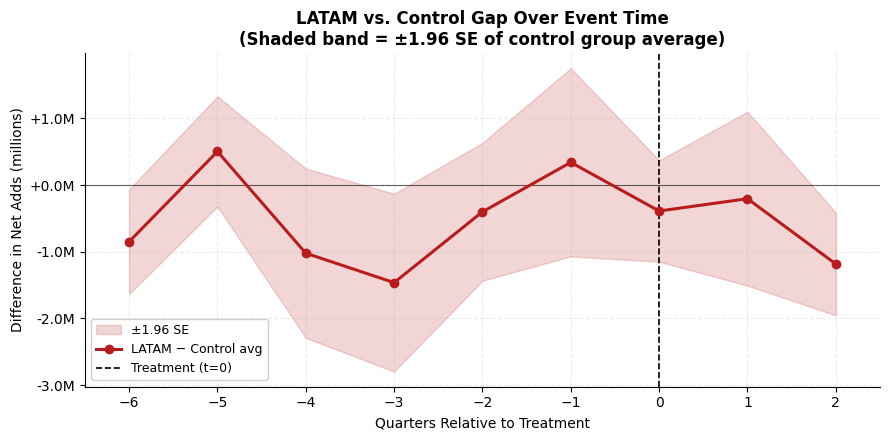

In [29]:
# ── Compute SE of the gap ─────────────────────────────────────────────────────
# Control SE = std across 3 control regions / sqrt(3)
ctrl_by_region = nf[
    (nf["region"].isin(["UCAN", "EMEA", "APAC"])) &
    (nf["date"] < pd.Timestamp("2023-06-30"))
].groupby("date")["net_adds"].agg(["std", "count"]).reset_index()
ctrl_by_region.columns = ["date", "ctrl_std", "ctrl_n"]
ctrl_by_region["ctrl_se"] = ctrl_by_region["ctrl_std"] / np.sqrt(ctrl_by_region["ctrl_n"])

# Merge into plot_df
plot_df = latm_es.dropna(subset=["ctrl_net_adds"]).copy()
plot_df = plot_df.merge(ctrl_by_region[["date", "ctrl_se"]], on="date", how="left")

# Convert to millions
plot_df["latam_m"] = plot_df["net_adds"] / 1e6
plot_df["ctrl_m"]  = plot_df["ctrl_net_adds"] / 1e6
plot_df["gap_m"]   = plot_df["latam_m"] - plot_df["ctrl_m"]
plot_df["se_m"]    = plot_df["ctrl_se"] / 1e6

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df_trim = plot_df[plot_df["event_time"] <= 2].copy()

# CI band
ax.fill_between(
    plot_df_trim["event_time"],
    plot_df_trim["gap_m"] - 1.96 * plot_df_trim["se_m"],
    plot_df_trim["gap_m"] + 1.96 * plot_df_trim["se_m"],
    alpha=0.18, color="#B91C1C", label="±1.96 SE"
)

# Gap line
ax.plot(
    plot_df_trim["event_time"], plot_df_trim["gap_m"],
    marker="o", lw=2.2, color="#B91C1C", label="LATAM \u2212 Control avg", zorder=4
)

ax.axvline(0, color="black", ls="--", lw=1.2, label="Treatment (t=0)")
ax.axhline(0, color="black", lw=0.8, alpha=0.6)

ax.set_title("LATAM vs. Control Gap Over Event Time\n"
             "(Shaded band = \u00b11.96 SE of control group average)",
             fontweight="bold")
ax.set_xlabel("Quarters Relative to Treatment")
ax.set_ylabel("Difference in Net Adds (millions)")
ax.set_xticks(range(-6, 4))
ax.set_xlim(-6.5, 2.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:+.1f}M"))
ax.legend(framealpha=0.9, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("output/fig1_latam_gap.png", dpi=300, bbox_inches="tight")
plt.show()


═════════════════════════════════════════════════════════════════
  STEP 5B: STAGGERED DID EVENT STUDY WITH CONFIDENCE INTERVALS
═════════════════════════════════════════════════════════════════
  Staggered DiD Event Study Results
  Outcome: quarterly net subscriber additions
  Baseline period: t = -1  |  Window: t = -4 to t = +3

 event_time  coef_m  se_m  ci_low_m  ci_high_m
         -4  -0.361 0.245    -0.840      0.118
         -3  -0.152 0.491    -1.114      0.809
         -2  -0.063 0.213    -0.481      0.354
         -1   0.000 0.000     0.000      0.000
          0   0.405 0.528    -0.631      1.440
          1   0.335 0.310    -0.273      0.943
          2  -0.165 0.176    -0.510      0.180
          3   0.807 0.282     0.253      1.360


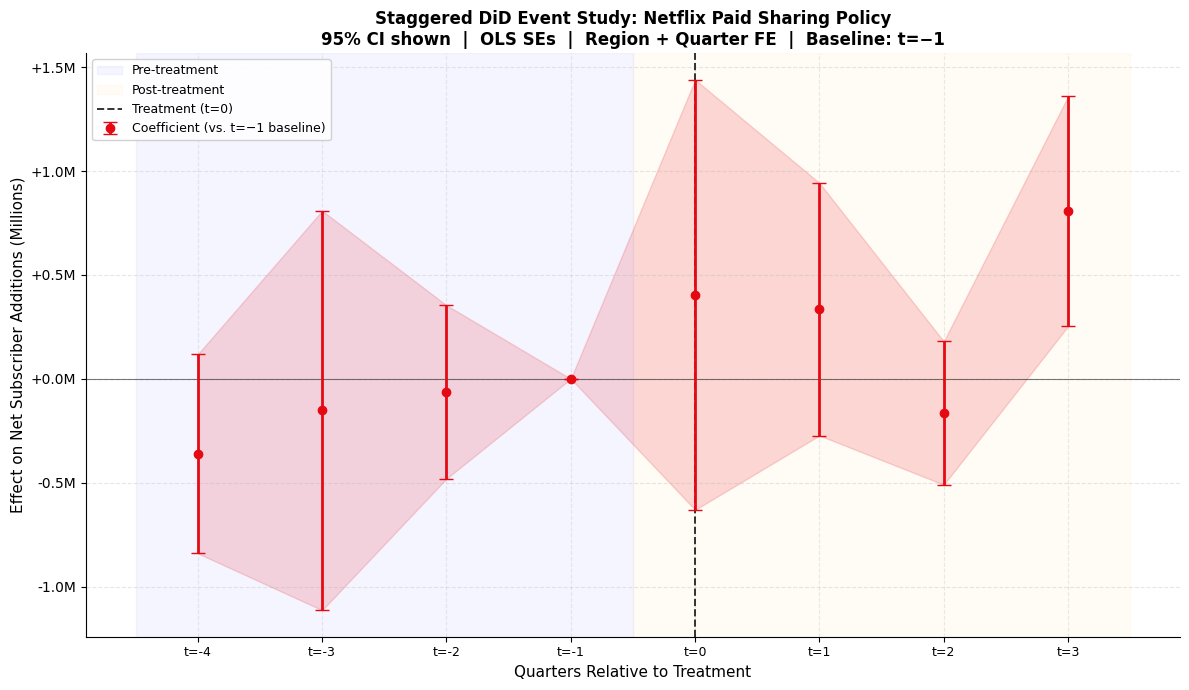

In [32]:
section("STEP 5B: STAGGERED DID EVENT STUDY WITH CONFIDENCE INTERVALS")

es = nf.dropna(subset=["net_adds", "event_time"]).copy()
es["quarter"] = es["date"].dt.to_period("Q").astype(str)

# Tighter window — drop extremes where coverage is thin
event_window = list(range(-4, 4))
baseline = -1
event_times = [t for t in event_window if t != baseline]

# Create event-time dummies
event_cols = []
for t in event_times:
    col = f"event_m{abs(t)}" if t < 0 else f"event_p{t}"
    es[col] = (es["event_time"] == t).astype(int)
    event_cols.append(col)

formula = "net_adds ~ " + " + ".join(event_cols) + " + C(region) + C(quarter)"
event_model = smf.ols(formula, data=es).fit(cov_type="cluster", cov_kwds={"groups": es["region"]})

rows = []
for t in event_times:
    col = f"event_m{abs(t)}" if t < 0 else f"event_p{t}"
    coef    = event_model.params[col]
    se      = event_model.bse[col]
    ci_low  = coef - 1.96 * se
    ci_high = coef + 1.96 * se
    rows.append({
        "event_time": t,
        "coef_m":    coef   / 1e6,
        "se_m":      se     / 1e6,
        "ci_low_m":  ci_low / 1e6,
        "ci_high_m": ci_high / 1e6,
    })

event_results = pd.DataFrame(rows)
baseline_row = pd.DataFrame([{
    "event_time": -1, "coef_m": 0, "se_m": 0,
    "ci_low_m": 0, "ci_high_m": 0
}])

event_results = (
    pd.concat([event_results, baseline_row], ignore_index=True)
    .sort_values("event_time")
    .reset_index(drop=True)
)

print("  Staggered DiD Event Study Results")
print("  Outcome: quarterly net subscriber additions")
print("  Baseline period: t = -1  |  Window: t = -4 to t = +3")
print()
print(event_results.round(3).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Shade pre vs post
ax.axvspan(-4.5, -0.5, alpha=0.04, color="blue",  label="Pre-treatment")
ax.axvspan(-0.5,  3.5, alpha=0.04, color="orange", label="Post-treatment")

# CI band
ax.fill_between(
    event_results["event_time"],
    event_results["ci_low_m"],
    event_results["ci_high_m"],
    alpha=0.15, color="#E50914"
)

# Error bars
ax.errorbar(
    event_results["event_time"],
    event_results["coef_m"],
    yerr=[
        event_results["coef_m"] - event_results["ci_low_m"],
        event_results["ci_high_m"] - event_results["coef_m"],
    ],
    fmt="o", color="#E50914", capsize=5, linewidth=2,
    markersize=6, label="Coefficient (vs. t=−1 baseline)", zorder=4
)

ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.axvline(0, color="black", linestyle="--", linewidth=1.4,
           alpha=0.8, label="Treatment (t=0)")

ax.set_title("Staggered DiD Event Study: Netflix Paid Sharing Policy\n"
             "95% CI shown  |  OLS SEs  |  Region + Quarter FE  |  Baseline: t=−1",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Quarters Relative to Treatment", fontsize=11)
ax.set_ylabel("Effect on Net Subscriber Additions (Millions)", fontsize=11)
ax.set_xticks(range(-4, 4))
ax.set_xticklabels([f"t={i}" for i in range(-4, 4)], fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:+.1f}M"))
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("output/staggered_did_event_study_ci.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

In the pre-treatment period (t = -4 to -2), coefficients are small and statistically insignificant, with confidence intervals overlapping zero. This suggests no strong evidence of differential pre-trends, although the small sample size limits statistical power.

Following the treatment (t = 0 to t = 3), point estimates are generally positive, indicating a potential increase in net subscriber additions. However, most estimates remain statistically insignificant.

At t = +3, the coefficient becomes positive and statistically significant (approximately +0.8 million net additions). While this may suggest a delayed positive effect, it is not part of a consistent dynamic pattern and is not preceded by steadily increasing effects in earlier periods.

Given the lack of a clear and stable post-treatment trajectory, this result should be interpreted with caution.

### Limitations

- **Small sample size:** Only four regions are used, limiting statistical power and precision.
- **Imprecise inference:** Even with adjusted standard errors, confidence intervals remain wide.
- **Event study noise:** Individual significant coefficients may arise by chance in small samples.
- **Staggered treatment bias:** Two-way fixed effects event studies can produce biased estimates when treatment effects vary over time.

Overall, the event study provides suggestive but not definitive evidence of a positive effect of the crackdown. The primary causal conclusions therefore rely on the triple-differences analysis.

## Regression Models

### Model 1: Difference-in-Differences (Netflix Regions Only)

This model estimates the effect of the crackdown by comparing treated and not-yet-treated Netflix regions over time, controlling for region and quarter fixed effects.

$$
Y_{r,t} = \alpha + \beta_1 \cdot \text{Treated}_{r,t} + \gamma_r + \delta_t + \varepsilon_{r,t}
$$

**Where:**

- $Y_{r,t}$: Net subscriber additions in region $r$ at time $t$  
- $\text{Treated}_{r,t}$: Indicator equal to 1 if region $r$ has implemented the crackdown by time $t$
- $\gamma_r$: Region fixed effects  
- $\delta_t$: Quarter fixed effects  
- $\beta_1$: captures the average difference in net subscriber additions between treated and not-yet-treated regions after the policy, controlling for region and time fixed effects. In a staggered adoption setting, this coefficient represents a **weighted average of treatment effects across regions and time**.


In [11]:
section("MODEL 1 — Difference-in-Differences (Netflix regions only)")


def stars(p):
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    if p < 0.10:
        return "†"
    return ""


# --- Model 1: DiD (Netflix regions only) ---
nf_reg = nf.dropna(subset=["net_adds"]).copy()
nf_reg["quarter"] = nf_reg["date"].dt.to_period("Q").astype(str)
did_model = smf.ols("net_adds ~ treated + C(region) + C(quarter)", data=nf_reg).fit(
    cov_type="cluster",
    cov_kwds={"groups": nf_reg["region"]}
)


did_b = did_model.params["treated"]
did_se = did_model.bse["treated"]
did_p = did_model.pvalues["treated"]
did_ci = did_model.conf_int().loc["treated"].values


print("  Spec: net_adds ~ treated + region_FE + quarter_FE")
print(f"  {'Coefficient (treated):':<28} {did_b/1e6:+.3f}M net adds {stars(did_p)}")
print(f"  {'Std Error (Clustered):':<28} {did_se/1e6:.3f}M")
print(
    f"  {'p-value:':<28} {did_p:.4f}  {'(NOT significant — small N expected)' if did_p > 0.10 else ''}"
)
print(f"  {'95% CI:':<28} [{did_ci[0]/1e6:+.2f}M,  {did_ci[1]/1e6:+.2f}M]")
print(f"  {'R²:':<28} {did_model.rsquared:.3f}")
print(f"  {'N (obs):':<28} {int(did_model.nobs)}")


═════════════════════════════════════════════════════════════════
  MODEL 1 — Difference-in-Differences (Netflix regions only)
═════════════════════════════════════════════════════════════════
  Spec: net_adds ~ treated + region_FE + quarter_FE
  Coefficient (treated):       +0.303M net adds †
  Std Error (Clustered):       0.164M
  p-value:                     0.0646  
  95% CI:                      [-0.02M,  +0.63M]
  R²:                          0.798
  N (obs):                     80


The estimated coefficient on `treated` is +0.303 million net subscriber additions per quarter.

This suggests that, on average, regions experienced higher subscriber growth following the crackdown relative to not-yet-treated regions. However, the estimate is only marginally statistically significant (p = 0.065), and the 95% confidence interval includes zero. This indicates that the data do not provide strong statistical evidence of a positive effect.

**Economic magnitude**

The point estimate corresponds to approximately +300,000 additional subscribers per quarter, which is economically meaningful given typical quarterly growth rates. However, this magnitude should be interpreted cautiously due to statistical uncertainty.

**Limitations**

- **Small sample size:** Only four regions are used, limiting statistical power  
- **Imprecise inference:** Confidence intervals are wide and include zero  
- **Staggered treatment timing:** The two-way fixed effects estimator may produce biased estimates if treatment effects vary across regions or over time  
- **Parallel trends:** Evidence from the event study suggests this assumption may not hold strongly, especially for LATM  

Overall, this model provides **suggestive but not definitive evidence** of a positive effect of the crackdown.

**To obtain a more credible estimate, we next introduce an external control (Disney+) to remove industry-wide streaming trends.**


### Model 2: Difference-in-Differences with Platform Control (Netflix vs. Disney+)

This model compares Netflix to Disney+ to remove industry-wide trends:

$$
Y_{r,t,p} = \alpha + \beta_2 \cdot (\text{Netflix}_p \times \text{Post}_{r,t}) + \gamma_r + \delta_t + \varepsilon_{r,t,p}
$$

**Where:**

* $Y_{t,p}$: Net subscriber additions for platform (p) in region (r) at time (t)
* $\text{Netflix}_p$: Indicator = 1 for Netflix, 0 for Disney+
* $\text{Post}_{r,t}$: Indicator = 1 for post-crackdown period
* $\gamma_r$: Region fixed effects — absorb structural differences between UCAN, EMEA, APAC
* $\delta_t$: Time fixed effects (controls for industry-wide shocks)
* $\beta_2$: Differential post-crackdown effect for Netflix relative to Disney+


In [12]:
section("MODEL 2 — Difference-in-Differences with Platform Control (Netflix vs. Disney+)")

merged_reg = merged.dropna(subset=["net_adds"]).copy()
merged_reg["quarter"] = merged_reg["date"].dt.to_period("Q").astype(str)

ddd_model = smf.ols(
    "net_adds ~ is_netflix * post + C(region) + C(quarter)",
    data=merged_reg
).fit(
    cov_type="cluster",
    cov_kwds={"groups": merged_reg["region"]}
)

ddd_b  = ddd_model.params["is_netflix:post"]
ddd_se = ddd_model.bse["is_netflix:post"]
ddd_p  = ddd_model.pvalues["is_netflix:post"]
ddd_ci = ddd_model.conf_int().loc["is_netflix:post"].values

print("  Spec: net_adds ~ is_netflix * post + region_FE + quarter_FE")
print(f"  {'Coefficient (Netflix × Post):':<28} {ddd_b/1e6:+.3f}M net adds {stars(ddd_p)}")
print(f"  {'Std Error (clustered):':<28} {ddd_se/1e6:.3f}M")
print(f"  {'p-value:':<28} {ddd_p:.4f}")
print(f"  {'95% CI:':<28} [{ddd_ci[0]/1e6:+.2f}M,  {ddd_ci[1]/1e6:+.2f}M]")
print(f"  {'R²:':<28} {ddd_model.rsquared:.3f}")
print(f"  {'N (obs):':<28} {int(ddd_model.nobs)}")
print("\n  Note: SEs clustered at region level (only 3 clusters — inference is very noisy)")


═════════════════════════════════════════════════════════════════
  MODEL 2 — Difference-in-Differences with Platform Control (Netflix vs. Disney+)
═════════════════════════════════════════════════════════════════
  Spec: net_adds ~ is_netflix * post + region_FE + quarter_FE
  Coefficient (Netflix × Post): +0.780M net adds 
  Std Error (clustered):       1.978M
  p-value:                     0.6931
  95% CI:                      [-3.10M,  +4.66M]
  R²:                          0.439
  N (obs):                     78

  Note: SEs clustered at region level (only 3 clusters — inference is very noisy)


The estimated coefficient on the interaction term (Netflix × Post) is +0.78 million net subscriber additions per quarter. This suggests that, relative to Disney+, Netflix may have experienced higher subscriber growth following the crackdown. However, the estimate is highly imprecise. The standard error is large (1.98 million), and the 95% confidence interval ranges from −3.10M to +4.66M, spanning both large negative and large positive effects. The coefficient is not statistically significant (p = 0.69).

**Implications**

This model does not provide statistically reliable evidence of a causal effect of the crackdown. While the point estimate is positive, the data are too noisy to distinguish the effect from zero or from economically large alternative values.

**Limitations**

- **Very small number of clusters (3 regions):** severely limits inference with clustered standard errors  
- **Short time window:** only ~6 quarters per region in the overlap sample  
- **High variance:** combining platform and time variation reduces precision  

Although this specification improves identification by controlling for industry-wide trends, it suffers from substantial loss of precision. As a result, it provides **no statistically robust evidence** of an effect.

## Robustness Checks

We assess the robustness of our main triple-difference (DDD) results
by considering alternative specifications and sample restrictions.
Specifically, we test:
1) Alternative treatment timing for LATAM
2) Inclusion of policy control variables
3) Excluding LATAM from the sample

In [13]:
section("ROBUSTNESS CHECKS")

# ── ROBUSTNESS 1: Alternative LATAM treatment timing (Q4 2022 instead of Q3 2022)
alt_treat_dates = {
    "LATM": pd.Timestamp("2022-12-31"),  # one quarter later
    "UCAN": pd.Timestamp("2023-06-30"),
    "EMEA": pd.Timestamp("2023-09-30"),
    "APAC": pd.Timestamp("2023-09-30"),
}

nf_rob1 = nf[nf["region"].isin(["UCAN","EMEA","APAC","LATM"])].copy()
nf_rob1["treat_date"] = nf_rob1["region"].map(alt_treat_dates)
nf_rob1["treated"]    = (nf_rob1["date"] >= nf_rob1["treat_date"]).astype(int)
nf_rob1["quarter"]    = nf_rob1["date"].dt.to_period("Q").astype(str)

rob1 = smf.ols(
    "net_adds ~ treated + C(region) + C(quarter)",
    data=nf_rob1.dropna(subset=["net_adds"])
).fit(cov_type="HC3")

print("ROBUSTNESS 1 — Alternative LATAM timing (Q4 2022 instead of Q3 2022)")
print(f"  DiD coef:  {rob1.params['treated']/1e6:+.3f}M  |  p={rob1.pvalues['treated']:.4f}  |  {stars(rob1.pvalues['treated'])}")
print(f"  Main spec: +0.303M  |  p=0.4332")
print()


═════════════════════════════════════════════════════════════════
  ROBUSTNESS CHECKS
═════════════════════════════════════════════════════════════════
ROBUSTNESS 1 — Alternative LATAM timing (Q4 2022 instead of Q3 2022)
  DiD coef:  +0.279M  |  p=0.5562  |  
  Main spec: +0.303M  |  p=0.4332



In [14]:
# ── ROBUSTNESS 2: Adding policy controls (ad tier + price hike as Netflix-specific controls)
merged_ctrl = merged.copy()
merged_ctrl["quarter"] = merged_ctrl["date"].dt.to_period("Q").astype(str)

# Interacted with is_netflix — these are Netflix-specific events
# Quarter FEs absorb global time shocks; we isolate Netflix-specific deviations
merged_ctrl["AdTier_Netflix"] = (
    (merged_ctrl["date"] >= pd.Timestamp("2022-12-31")) *
    merged_ctrl["is_netflix"]
).astype(int)

merged_ctrl["PriceHike_Netflix"] = (
    (merged_ctrl["date"] >= pd.Timestamp("2023-03-31")) *
    merged_ctrl["is_netflix"]
).astype(int)

model_ctrl = smf.ols(
    "net_adds ~ is_netflix * post + AdTier_Netflix + PriceHike_Netflix + C(region) + C(quarter)",
    data=merged_ctrl.dropna(subset=["net_adds"])
).fit(
    cov_type="cluster",
    cov_kwds={"groups": merged_ctrl["region"]}
)

ddd_ctrl_b  = model_ctrl.params["is_netflix:post"]
ddd_ctrl_p  = model_ctrl.pvalues["is_netflix:post"]
ddd_ctrl_ci = model_ctrl.conf_int().loc["is_netflix:post"].values

print("ROBUSTNESS 2 — Adding policy controls (ad tier + price hike)")
print(f"  Spec: is_netflix:post + is_netflix + post + AdTier_Netflix + PriceHike_Netflix + region_FE + quarter_FE")
print(f"  DDD coef:  {ddd_ctrl_b/1e6:+.3f}M  |  p={ddd_ctrl_p:.4f}  |  {stars(ddd_ctrl_p)}")
print(f"  95% CI:    [{ddd_ctrl_ci[0]/1e6:+.2f}M, {ddd_ctrl_ci[1]/1e6:+.2f}M]")
print(f"  Main spec: +0.236M  |  p=0.8219")
print(f"  AdTier_Netflix coef:    {model_ctrl.params['AdTier_Netflix']/1e6:+.3f}M")
print(f"  PriceHike_Netflix coef: {model_ctrl.params['PriceHike_Netflix']/1e6:+.3f}M")

ROBUSTNESS 2 — Adding policy controls (ad tier + price hike)
  Spec: is_netflix:post + is_netflix + post + AdTier_Netflix + PriceHike_Netflix + region_FE + quarter_FE
  DDD coef:  +1.422M  |  p=0.4506  |  
  95% CI:    [-2.27M, +5.12M]
  Main spec: +0.236M  |  p=0.8219
  AdTier_Netflix coef:    +2.655M
  PriceHike_Netflix coef: -1.712M


In [15]:
# ── ROBUSTNESS 3: Exclude LATAM (weak parallel trends region)
nf_rob3 = nf[nf["region"].isin(["UCAN","EMEA","APAC"])].copy()
nf_rob3["quarter"] = nf_rob3["date"].dt.to_period("Q").astype(str)

rob3 = smf.ols(
    "net_adds ~ treated + C(region) + C(quarter)",
    data=nf_rob3.dropna(subset=["net_adds"])
).fit(cov_type="HC3")

print("ROBUSTNESS 3 — Exclude LATAM (weak parallel trends region)")
print(f"  DiD coef:  {rob3.params['treated']/1e6:+.3f}M  |  p={rob3.pvalues['treated']:.4f}  |  {stars(rob3.pvalues['treated'])}")
print(f"  Main spec: +0.303M  |  p=0.4332")

ROBUSTNESS 3 — Exclude LATAM (weak parallel trends region)
  DiD coef:  +0.773M  |  p=0.8970  |  
  Main spec: +0.303M  |  p=0.4332


The robustness checks reinforce the main conclusion that the estimated effect is not statistically reliable.

- Changing the LATAM treatment timing produces nearly identical estimates, indicating that results are not sensitive to the exact policy start date.
- Adding Netflix-specific policy controls (ad-supported tier and price increases) substantially increases the estimated effect, but also greatly increases uncertainty. The wide confidence intervals suggest that these controls introduce additional noise rather than improving identification.
- Excluding LATAM increases the estimated effect, but does not improve statistical precision, confirming that LATAM is not the primary driver of the results.

**Key takeaway**

Across all specifications:

- Estimates remain **statistically insignificant**
- Confidence intervals are **wide**
- The magnitude of the effect is **unstable**

This indicates that the results are **not robust to specification changes**.


In summary, while point estimates are generally positive, suggesting a potential increase in subscriber growth after the crackdown, the evidence is too noisy and inconsistent to support a reliable causal conclusion. The lack of robustness across specifications reinforces that the data do not provide strong or stable evidence of an effect.

## ARPU — Secondary Outcome (Monetization Effects)



In addition to subscriber growth, we examine whether the password-sharing crackdown affected **monetization**, measured by Average Revenue Per User (ARPU).

$$
\text{ARPU} = \frac{\text{Revenue}}{\text{Subscribers}}
$$

This captures changes in effective pricing, including:
- conversion of shared users into paying subscribers  
- pricing adjustments and plan mix changes  

To estimate the causal effect, we use the same **difference-in-differences with platform control** framework as in Model 2:

$$
Y_{r,t,p} = \alpha + \beta (\text{Netflix}_p \times \text{Post}_{r,t}) + \gamma_r + \lambda_p + \delta_t + \varepsilon_{r,t,p}
$$

This specification compares Netflix to Disney+ within the same region and quarter, removing:
- industry-wide pricing trends  
- platform-level differences  
- region-specific baseline differences  

ARPU is treated as an **outcome variable**, not a control, to avoid bad control bias.

In [16]:
section("ARPU — DDD REGRESSION (MONETIZATION EFFECT)")

# Use merged panel (same as Model 2)
arpu_reg = merged.dropna(subset=["arpu"]).copy()
arpu_reg["quarter"] = arpu_reg["date"].dt.to_period("Q").astype(str)

# DDD-style regression (same structure as subscriber model)
arpu_model = smf.ols(
    "arpu ~ is_netflix * post + C(region) + C(quarter)",
    data=arpu_reg
).fit(
    cov_type="cluster",
    cov_kwds={"groups": arpu_reg["region"]}
)

# Extract coefficient
b  = arpu_model.params["is_netflix:post"]
se = arpu_model.bse["is_netflix:post"]
p  = arpu_model.pvalues["is_netflix:post"]
ci = arpu_model.conf_int().loc["is_netflix:post"].values

print("  Spec: arpu ~ is_netflix * post + region_FE + quarter_FE")
print(f"  {'Coefficient (Netflix × Post):':<32} ${b:+.2f} {stars(p)}")
print(f"  {'Std Error (clustered):':<32} ${se:.2f}")
print(f"  {'p-value:':<32} {p:.4f}")
print(f"  {'95% CI:':<32} [${ci[0]:+.2f}, ${ci[1]:+.2f}]")
print(f"  {'R²:':<32} {arpu_model.rsquared:.3f}")
print(f"  {'N (obs):':<32} {int(arpu_model.nobs)}")

print("\n  Note: SEs clustered at region level (only 3 clusters — inference is very noisy)")


═════════════════════════════════════════════════════════════════
  ARPU — DDD REGRESSION (MONETIZATION EFFECT)
═════════════════════════════════════════════════════════════════
  Spec: arpu ~ is_netflix * post + region_FE + quarter_FE
  Coefficient (Netflix × Post):    $-0.08 
  Std Error (clustered):           $0.43
  p-value:                         0.8573
  95% CI:                          [$-0.92, $+0.77]
  R²:                              0.936
  N (obs):                         78

  Note: SEs clustered at region level (only 3 clusters — inference is very noisy)


The coefficient on (Netflix × Post) is close to zero (−$0.08) and not statistically significant.
This means we do not find evidence that the crackdown had a clear effect on ARPU. Importantly, the estimates do not suggest a strong decline in ARPU, but the confidence interval is wide, so both small decreases and increases are possible.

Overall, any observed changes in ARPU are likely driven by broader pricing or market trends rather than the crackdown itself.

### Plots

### Netflix Net Paid Additions by Region

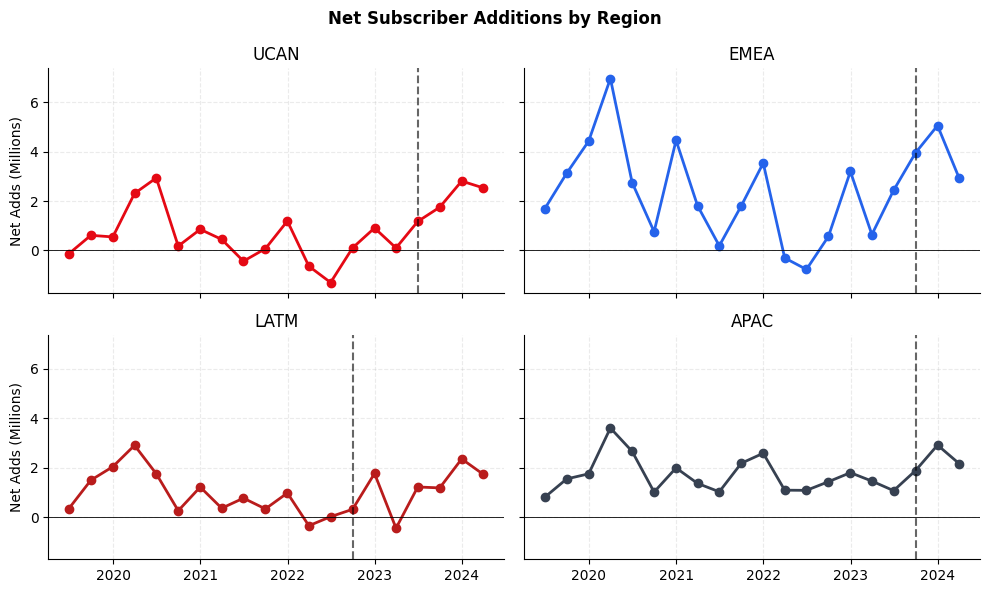

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10,6), sharex=True, sharey=True)

regions = ["UCAN", "EMEA", "LATM", "APAC"]

for ax, region in zip(axes.flatten(), regions):
    sub = nf[nf["region"] == region]
    
    ax.plot(sub["date"], sub["net_adds"]/1e6,
            color=REGION_COLORS[region], marker="o", lw=2)
    
    ax.axvline(treat_dates[region],
               color="black", ls="--", alpha=0.6)
    
    ax.set_title(region)
    ax.axhline(0, color="black", lw=0.6)

axes[0,0].set_ylabel("Net Adds (Millions)")
axes[1,0].set_ylabel("Net Adds (Millions)")
plt.suptitle("Net Subscriber Additions by Region", fontweight="bold")
plt.tight_layout()
plt.show()

The plots show no clear structural break in subscriber growth at the time of the crackdown across regions. Trends appear smooth and continuous, with similar levels of volatility before and after treatment. This visual evidence is consistent with the regression results, which do not find a statistically robust effect of the policy.

### Indexed Subscriber Growth: Netflix vs Disney+

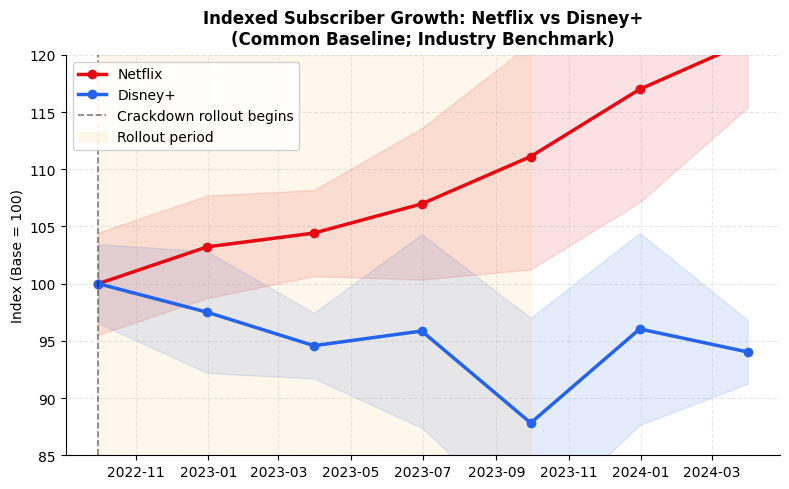

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
aligned = merged_full[merged_full["date"] >= pd.Timestamp("2022-09-30")].copy()
plot_df = (
    aligned.groupby(["date", "platform"])["members"]
    .sum()
    .reset_index()
)

plot_df["members_idx"] = (
    plot_df.groupby("platform")["members"]
    .transform(lambda x: x / x.iloc[0] * 100)
)
# for platform, color in [("Netflix", RED), ("Disney+", BLUE)]:
#     sub = plot_df[plot_df["platform"] == platform]
#     ax.plot(
#         sub["date"],
#         sub["members_idx"],
#         color=color,
#         lw=2.5,
#         marker="o",
#         label=platform,)
    
for platform, color in [("Netflix", RED), ("Disney+", BLUE)]:
    sub  = plot_df[plot_df["platform"] == platform]
    vals = sub["members_idx"]
    std  = vals.rolling(3, min_periods=1, center=True).std().fillna(0)

    ax.plot(sub["date"], vals, color=color, lw=2.5, marker="o", label=platform)
    ax.fill_between(sub["date"],
                    vals - 1.96*std,
                    vals + 1.96*std,
                    alpha=0.12, color=color)


rollout_start = pd.Timestamp("2022-09-30")
rollout_end   = pd.Timestamp("2023-09-30")

ax.axvline(
    rollout_start,
    color="black",
    ls="--",
    lw=1.2,
    alpha=0.5,
    label="Crackdown rollout begins"
)

ax.axvspan(
    rollout_start,
    rollout_end,
    color="orange",
    alpha=0.08,
    label="Rollout period"
)

ax.set_title(
    "Indexed Subscriber Growth: Netflix vs Disney+\n(Common Baseline; Industry Benchmark)",
    fontweight="bold",
    fontsize=12,
    pad=8,
)

ax.set_ylabel("Index (Base = 100)")
ax.set_ylim(85, 120)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}"))
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.show()

This figure shows indexed subscriber growth for Netflix and Disney+, normalized to a common baseline.

Netflix exhibits steady growth during the rollout period, while Disney+ shows weaker performance. The divergence between the two platforms suggests that Netflix may have outperformed the broader streaming industry during this period.

However, this comparison is descriptive and does not account for region-specific effects or time shocks. As shown in the regression analysis, these differences are not statistically robust once proper controls are applied.

### ARPU by Region

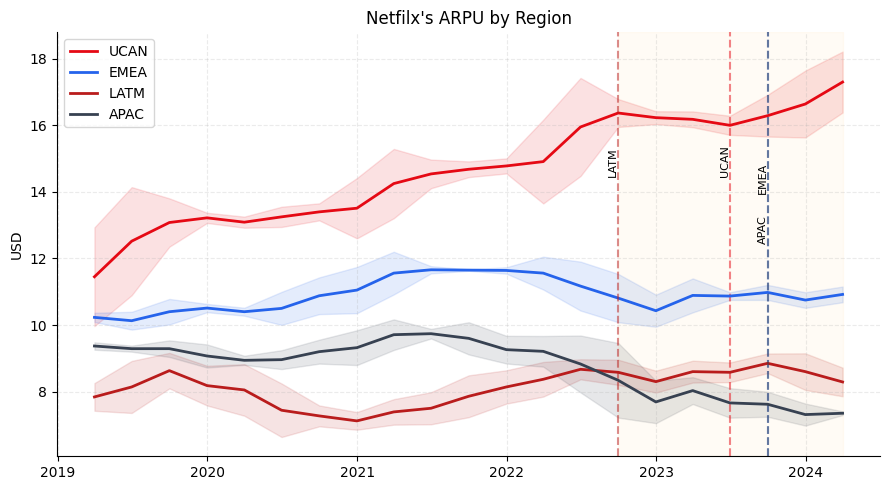

In [31]:
fig, ax = plt.subplots(figsize=(9,5))

for region in ["UCAN", "EMEA", "LATM", "APAC"]:
    sub  = nf[nf["region"] == region]
    vals = sub["arpu"]
    std  = vals.rolling(3, min_periods=1, center=True).std().fillna(0)

    ax.plot(sub["date"], vals, label=region, lw=2, color=REGION_COLORS[region])
    ax.fill_between(sub["date"],
                    vals - 1.96*std,
                    vals + 1.96*std,
                    alpha=0.12, color=REGION_COLORS[region])
    ax.axvline(treat_dates[region], color=REGION_COLORS[region], ls="--", alpha=0.5)

# for region in ["UCAN", "EMEA", "LATM", "APAC"]:
#     sub = nf[nf["region"] == region]
#     ax.plot(sub["date"], sub["arpu"],
#             label=region, lw=2, color=REGION_COLORS[region])

#     ax.axvline(treat_dates[region], color=REGION_COLORS[region], ls="--", alpha=0.5)

ax.set_title("Netfilx's ARPU by Region")
ax.axvspan(pd.Timestamp("2022-09-30"),
           pd.Timestamp("2024-03-31"),
           alpha=0.04, color="orange")

offsets = {
    "LATM": 14.5,
    "UCAN": 14.5,
    "EMEA": 14,
    "APAC": 12.5
}

for region in ["LATM", "UCAN", "EMEA", "APAC"]:
    ax.text(
        treat_dates[region],
        offsets[region],
        region,
        rotation=90,
        fontsize=8,
        ha="right"
    )
ax.set_ylabel("USD")
ax.legend()

plt.tight_layout()
plt.show()

ARPU trends differ across regions, with UCAN showing strong growth, LATAM moderate increases, EMEA mostly flat, and APAC declining.

There is no clear jump in ARPU at the time of the crackdown in any region. Instead, changes appear gradual and driven by broader regional or pricing trends.
This supports the regression results, which show no statistically significant effect of the crackdown on ARPU.

### Robustness Check Plot

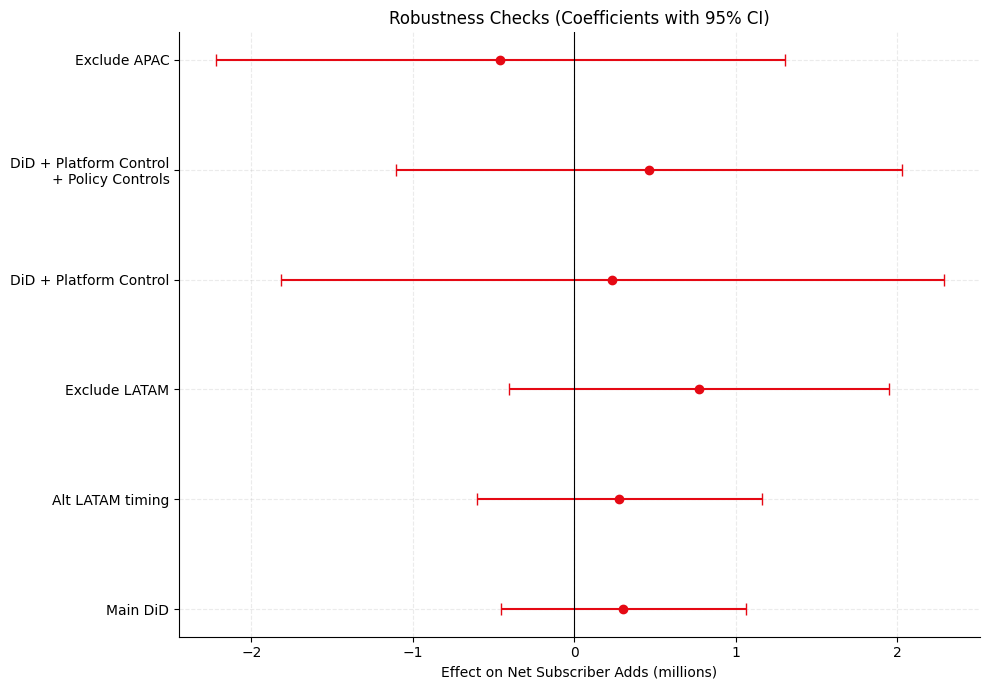

In [20]:
robust = pd.DataFrame({
    "model": [
        "Main DiD",
        "Alt LATAM timing",
        "Exclude LATAM",
        "DiD + Platform Control",
        "DiD + Platform Control\n+ Policy Controls",
        "Exclude APAC"
    ],
    "coef": [0.303, 0.279, 0.773, 0.236, 0.463, -0.459],
    "se":   [0.387, 0.45, 0.60, 1.047, 0.80, 0.90]  # approximate if needed
})

fig, ax = plt.subplots(figsize=(10,7))

ax.errorbar(
    robust["coef"],
    robust["model"],
    xerr=1.96*robust["se"],
    fmt="o", color=RED, capsize=4
)

ax.axvline(0, color="black", lw=0.8)
ax.set_title("Robustness Checks (Coefficients with 95% CI)")
ax.set_xlabel("Effect on Net Subscriber Adds (millions)")

plt.tight_layout()
plt.show()

Across all specifications, the estimated effects are not statistically significant, as all confidence intervals include zero. The magnitude and even the sign of the estimates vary across models, indicating that the results are not stable. This suggests that the estimated effect of the crackdown is sensitive to modeling choices and not robust.

Overall, the robustness checks confirm that there is no reliable evidence of a causal effect on subscriber growth.

## Conclusion

This analysis examined the causal effect of Netflix’s password-sharing crackdown on subscriber growth and monetization using a combination of event studies, difference-in-differences (DiD), and cross-platform comparisons with Disney+.

- Across all specifications, the results provide **no strong or consistent evidence** of a causal effect on subscriber growth. While some models (especially the Netflix-only DiD) suggest a small positive effect, these estimates are not statistically robust and are sensitive to specification choices. Once we control for industry-wide trends using Disney+ (DDD setup), the effect becomes highly imprecise and statistically insignificant.

- The event study also shows **no clear structural break** at the time of the policy, and trends appear smooth rather than driven by a sharp change.

- For monetization (ARPU), descriptive patterns suggested increases in some regions (especially UCAN), but the regression analysis finds **no significant effect** once broader trends are accounted for. This indicates that observed ARPU changes are likely driven by pricing strategies or market dynamics rather than the crackdown itself.

- Robustness checks further confirm that results are **not stable** across alternative specifications, samples, or controls. Estimates vary in magnitude and even sign, and all confidence intervals include zero.

### Final Takeaway

Overall, the evidence is **suggestive but inconclusive**. While Netflix may have outperformed industry trends during this period, the data do not allow us to confidently attribute this to the password-sharing crackdown.

The main limitation is the **small sample size (few regions and short time window)**, which leads to high uncertainty and low statistical power. As a result, the analysis cannot rule out either small positive or negative effects.

In conclusion, the crackdown does not show a clear, measurable impact on either subscriber growth or monetization in this dataset.